# Crop-Yield Risk Forecasting — Rolling Windows + Strict Temporal Validation

This notebook implements the mentor-requested correction to the earlier circular risk model.

### What this notebook does
1. Uses **past-period features** to predict **later-period yield instability**.
2. Creates **rolling 3-year feature → 3-year future-target windows** to expand the sample.
3. Generates **150 potential rolling samples** (25 state–crop pairs × 6 windows); invalid target-CV rows are removed explicitly.
4. Evaluates the models in two complementary ways:
   - **Expanded blocked temporal split** for a larger train/test sample.
   - **Strict walk-forward validation**, where training targets end before the test target starts.
5. Keeps a separate **2016–2018 → 2019–2022 final holdout** to match the mentor's exact future-period request.
6. Compares:
   - M1: past mean yield
   - M2: past mean yield + past yield CV
   - M3: yield + rainfall variability + soil context
7. Reports accuracy, weighted F1, macro F1, balanced accuracy, confusion matrices, and random baselines.

> Important: rolling windows overlap in calendar years, so the 150 potential samples are not 150 fully independent observations. The strict walk-forward and final-holdout sections are included to keep the research interpretation conservative.


In [40]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

DATA_PATH = "data/final/agri_combined_datasets.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Year range:", int(df["year"].min()), "to", int(df["year"].max()))
print("States:", df["state"].nunique())
print("Crops:", df["crop"].nunique())
df.head()


Dataset shape: (6817, 25)
Year range: 2012 to 2022
States: 5
Crops: 5


,state,district,crop,year,area,production,yield,annual_rainfall,n_high,n_medium,...,k_medium,k_low,oc_high,oc_medium,oc_low,ph_alkaline,ph_acidic,ph_neutral,ec_nonsaline,ec_saline
0,andhra pradesh,alluri sitharama raju,Cotton(lint),2022,2682.0,7614.0,2.84,1080.7,3.26,54.11,...,44.99,29.87,27.25,64.48,8.27,0.12,18.93,80.95,99.81,0.19
1,andhra pradesh,anakapalli,Cotton(lint),2022,82.0,230.0,2.80,1080.7,12.10,25.02,...,22.88,8.79,12.98,25.62,61.40,0.62,0.10,99.27,98.99,1.01
2,andhra pradesh,anantapur,Cotton(lint),2012,28000.0,35000.0,1.25,536.0,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
3,andhra pradesh,anantapur,Cotton(lint),2013,37661.0,77316.0,2.05,501.7,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
4,andhra pradesh,anantapur,Cotton(lint),2014,73734.0,103779.0,1.41,437.8,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39


## 1. Prepare numeric modelling columns

In [41]:
soil_cols = [
    "n_high", "n_medium", "n_low",
    "p_high", "p_medium", "p_low",
    "k_high", "k_medium", "k_low",
    "oc_high", "oc_medium", "oc_low",
    "ph_alkaline", "ph_acidic", "ph_neutral",
    "ec_nonsaline", "ec_saline"
]

numeric_cols = [
    "year", "area", "production", "yield", "annual_rainfall"
] + soil_cols

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=["state", "crop", "year", "yield", "annual_rainfall"]
).copy()

print("Missing values in forecasting variables:")
print(df[["yield", "annual_rainfall"] + soil_cols].isna().sum())


Missing values in forecasting variables:
yield              0
annual_rainfall    0
n_high             0
n_medium           0
n_low              0
p_high             0
p_medium           0
p_low              0
k_high             0
k_medium           0
k_low              0
oc_high            0
oc_medium          0
oc_low             0
ph_alkaline        0
ph_acidic          0
ph_neutral         0
ec_nonsaline       0
ec_saline          0
dtype: int64


## 2. Aggregate district rows into a state–crop–year panel

In [42]:
def aggregate_state_crop_year(g):
    valid = g[
        g["area"].notna()
        & g["production"].notna()
        & (g["area"] > 0)
    ]

    if len(valid) > 0 and valid["area"].sum() > 0:
        yield_value = valid["production"].sum() / valid["area"].sum()
    else:
        yield_value = g["yield"].mean()

    out = {
        "yield": yield_value,
        "annual_rainfall": g["annual_rainfall"].mean()
    }

    for col in soil_cols:
        out[col] = g[col].mean()

    return pd.Series(out)

panel = (
    df.groupby(["state", "crop", "year"], as_index=False)
      .apply(aggregate_state_crop_year, include_groups=False)
      .reset_index(drop=True)
)

print("Panel shape:", panel.shape)
print("State-crop pairs:", panel.groupby(["state", "crop"]).ngroups)
print("Years per state-crop pair:")
print(panel.groupby(["state", "crop"])["year"].nunique().describe())
panel.head()


Panel shape: (275, 22)
State-crop pairs: 25
Years per state-crop pair:
count    25.0
mean     11.0
std       0.0
min      11.0
25%      11.0
50%      11.0
75%      11.0
max      11.0
Name: year, dtype: float64


,state,crop,year,yield,annual_rainfall,n_high,n_medium,n_low,p_high,p_medium,...,k_medium,k_low,oc_high,oc_medium,oc_low,ph_alkaline,ph_acidic,ph_neutral,ec_nonsaline,ec_saline
0,andhra pradesh,Cotton(lint),2012,2.615254,1127.376923,0.172308,13.055385,86.771538,46.235385,34.308846,...,30.437692,20.157692,21.792308,28.546154,49.623846,4.307692,0.278462,95.364615,94.221538,5.778462
1,andhra pradesh,Cotton(lint),2013,3.240232,1042.976923,0.172308,13.055385,86.771538,46.235385,34.308846,...,30.437692,20.157692,21.792308,28.546154,49.623846,4.307692,0.278462,95.364615,94.221538,5.778462
2,andhra pradesh,Cotton(lint),2014,3.356879,838.469231,0.172308,13.055385,86.771538,46.235385,34.308846,...,30.437692,20.157692,21.792308,28.546154,49.623846,4.307692,0.278462,95.364615,94.221538,5.778462
3,andhra pradesh,Cotton(lint),2015,2.732308,963.430769,0.172308,13.055385,86.771538,46.235385,34.308846,...,30.437692,20.157692,21.792308,28.546154,49.623846,4.307692,0.278462,95.364615,94.221538,5.778462
4,andhra pradesh,Cotton(lint),2016,3.332764,934.076923,0.172308,13.055385,86.771538,46.235385,34.308846,...,30.437692,20.157692,21.792308,28.546154,49.623846,4.307692,0.278462,95.364615,94.221538,5.778462


## 3. Generate all rolling 3-year forecasting samples

Each sample is:

**past 3 years of features → next 3 years of future instability**

Examples:

- 2012–2014 → 2015–2017
- 2013–2015 → 2016–2018
- 2014–2016 → 2017–2019
- 2015–2017 → 2018–2020
- 2016–2018 → 2019–2021
- 2017–2019 → 2020–2022

The target is the CV of yield in the later target window. Future-year data is used only to calculate the actual target label, not as an input feature.


In [43]:
F = 3
T = 3
rows = []

for (state, crop), g in panel.groupby(["state", "crop"]):
    g = g.sort_values("year").reset_index(drop=True)
    years = g["year"].astype(int).tolist()

    ymin, ymax = min(years), max(years)

    for s in range(ymin, ymax - (F + T) + 2):
        feat_years = list(range(s, s + F))
        targ_years = list(range(s + F, s + F + T))

        if not all(y in years for y in feat_years + targ_years):
            continue

        fw = g[g["year"].isin(feat_years)]
        tw = g[g["year"].isin(targ_years)]

        feat_yield_mean = fw["yield"].mean()
        feat_yield_std = fw["yield"].std()
        feat_yield_cv = (
            feat_yield_std / feat_yield_mean
            if feat_yield_mean != 0 else np.nan
        )

        feat_rain_mean = fw["annual_rainfall"].mean()
        feat_rain_std = fw["annual_rainfall"].std()
        feat_rain_cv = (
            feat_rain_std / feat_rain_mean
            if feat_rain_mean != 0 else np.nan
        )

        target_yield_mean = tw["yield"].mean()
        target_cv = (
            tw["yield"].std() / target_yield_mean
            if target_yield_mean != 0 else np.nan
        )

        row = {
            "state": state,
            "crop": crop,
            "feat_start": s,
            "feat_end": s + 2,
            "targ_start": s + 3,
            "targ_end": s + 5,
            "feat_yield_mean": feat_yield_mean,
            "feat_yield_std": feat_yield_std,
            "feat_yield_cv": feat_yield_cv,
            "feat_rain_mean": feat_rain_mean,
            "feat_rain_std": feat_rain_std,
            "feat_rain_cv": feat_rain_cv,
            "target_cv": target_cv
        }

        for col in soil_cols:
            row[col] = fw[col].mean()

        rows.append(row)

wdf_all = pd.DataFrame(rows)

print("Potential rolling samples:", len(wdf_all))
print("\nSamples per rolling origin:")
print(wdf_all.groupby(["feat_start","feat_end","targ_start","targ_end"]).size())

print("\nUndefined target CV rows:", wdf_all["target_cv"].isna().sum())

wdf = (
    wdf_all
    .dropna(subset=["target_cv"])
    .reset_index(drop=True)
)

print("Valid rolling samples:", len(wdf))
print("\nValid samples per rolling origin:")
print(wdf.groupby(["feat_start","feat_end","targ_start","targ_end"]).size())


Potential rolling samples: 150

Samples per rolling origin:
feat_start  feat_end  targ_start  targ_end
2012        2014      2015        2017        25
2013        2015      2016        2018        25
2014        2016      2017        2019        25
2015        2017      2018        2020        25
2016        2018      2019        2021        25
2017        2019      2020        2022        25
dtype: int64

Undefined target CV rows: 10
Valid rolling samples: 140

Valid samples per rolling origin:
feat_start  feat_end  targ_start  targ_end
2012        2014      2015        2017        24
2013        2015      2016        2018        24
2014        2016      2017        2019        23
2015        2017      2018        2020        23
2016        2018      2019        2021        23
2017        2019      2020        2022        23
dtype: int64


## 4. Model feature sets

Risk thresholds are always learned from the training target-CV distribution only.


In [44]:
feature_sets = {
    "Model 1: Past mean yield": [
        "feat_yield_mean"
    ],

    "Model 2: Past mean + yield CV": [
        "feat_yield_mean",
        "feat_yield_cv"
    ],

    "Model 3: Yield + climate variability + soil": [
        "feat_yield_mean",
        "feat_yield_cv",
        "feat_rain_mean",
        "feat_rain_std",
        "feat_rain_cv"
    ] + soil_cols
}

labels = ["Low", "Medium", "High"]

def fit_risk_thresholds(train_df):
    q33 = train_df["target_cv"].quantile(0.33)
    q67 = train_df["target_cv"].quantile(0.67)
    return q33, q67

def apply_risk_label(series, q33, q67):
    return series.apply(
        lambda cv: "Low" if cv <= q33
        else ("Medium" if cv <= q67 else "High")
    )

def train_and_predict(train_df, test_df, features,
                      n_estimators=200,
                      min_samples_leaf=1):
    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(medians).fillna(0)
    X_test = X_test.fillna(medians).fillna(0)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight="balanced",
        random_state=42,
        min_samples_leaf=min_samples_leaf
    )

    clf.fit(X_train, train_df["risk"])
    pred = clf.predict(X_test)
    return clf, pred

def metrics_row(name, y_true, pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Weighted F1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_true, pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, pred)
    }


# PART A — Expanded rolling-window temporal split

This section uses the expanded rolling dataset.

- **Training origins:** 2012, 2013, 2014
- **Later test origins:** 2015, 2016, 2017

This gives a much larger sample than the original 25 state–crop pairs.

**Caution:** neighbouring rolling windows overlap in calendar years, so these observations are temporally dependent. This section is useful for expanded-sample model comparison, but the strict walk-forward and final-holdout checks below should be used for stronger publication claims.


In [45]:
train_expanded = wdf[wdf["feat_start"].isin([2012, 2013, 2014])].copy()
test_expanded = wdf[wdf["feat_start"].isin([2015, 2016, 2017])].copy()

q33_exp, q67_exp = fit_risk_thresholds(train_expanded)

train_expanded["risk"] = apply_risk_label(
    train_expanded["target_cv"], q33_exp, q67_exp
)
test_expanded["risk"] = apply_risk_label(
    test_expanded["target_cv"], q33_exp, q67_exp
)

print("Training samples:", len(train_expanded))
print("Testing samples :", len(test_expanded))
print("Total used      :", len(train_expanded) + len(test_expanded))

print("\nTraining risk distribution:")
print(train_expanded["risk"].value_counts())

print("\nTesting risk distribution:")
print(test_expanded["risk"].value_counts())

print(f"\nTraining-only thresholds: q33={q33_exp:.4f}, q67={q67_exp:.4f}")


Training samples: 71
Testing samples : 69
Total used      : 140

Training risk distribution:
risk
Low       24
High      24
Medium    23
Name: count, dtype: int64

Testing risk distribution:
risk
Low       39
Medium    22
High       8
Name: count, dtype: int64

Training-only thresholds: q33=0.1188, q67=0.2867


In [46]:
expanded_results = {}
expanded_rows = []

for name, features in feature_sets.items():
    model, pred = train_and_predict(
        train_expanded,
        test_expanded,
        features,
        n_estimators=200,
        min_samples_leaf=1
    )

    expanded_results[name] = {
        "model": model,
        "pred": pred,
        "features": features
    }

    expanded_rows.append(
        metrics_row(name, test_expanded["risk"], pred)
    )

expanded_results_df = pd.DataFrame(expanded_rows)
expanded_results_df


,Model,Accuracy,Weighted F1,Macro F1,Balanced Accuracy
0,Model 1: Past mean yield,0.434783,0.455298,0.385191,0.428516
1,Model 2: Past mean + yield CV,0.434783,0.480259,0.404614,0.448329
2,Model 3: Yield + climate variability + soil,0.521739,0.561942,0.478156,0.532731


In [47]:
# Random chance-like baseline averaged over many runs
random_rows = []

Xtr_dummy = train_expanded[["feat_yield_mean"]]
Xte_dummy = test_expanded[["feat_yield_mean"]]

for seed in range(1000):
    dummy = DummyClassifier(strategy="stratified", random_state=seed)
    dummy.fit(Xtr_dummy, train_expanded["risk"])
    pred = dummy.predict(Xte_dummy)

    random_rows.append(
        metrics_row("Random baseline", test_expanded["risk"], pred)
    )

random_df = pd.DataFrame(random_rows)

print("===== RANDOM BASELINE (1000 RUNS) =====")
for col in ["Accuracy", "Weighted F1", "Macro F1", "Balanced Accuracy"]:
    print(
        f"{col}: "
        f"{random_df[col].mean():.3f} ± {random_df[col].std():.3f}"
    )


===== RANDOM BASELINE (1000 RUNS) =====
Accuracy: 0.336 ± 0.058
Weighted F1: 0.361 ± 0.058
Macro F1: 0.305 ± 0.055
Balanced Accuracy: 0.335 ± 0.073


In [48]:
for name, result in expanded_results.items():
    pred = result["pred"]

    print("=" * 85)
    print(name)
    print(pd.Series(
        metrics_row(name, test_expanded["risk"], pred)
    ))

    cm = confusion_matrix(
        test_expanded["risk"], pred, labels=labels
    )

    print("\nConfusion matrix:")
    print(pd.DataFrame(cm, index=labels, columns=labels))

    print("\nClassification report:")
    print(classification_report(
        test_expanded["risk"],
        pred,
        labels=labels,
        zero_division=0
    ))


Model 1: Past mean yield
Model                Model 1: Past mean yield
Accuracy                             0.434783
Weighted F1                          0.455298
Macro F1                             0.385191
Balanced Accuracy                    0.428516
dtype: object

Confusion matrix:
        Low  Medium  High
Low      20       9    10
Medium    9       6     7
High      1       3     4

Classification report:
              precision    recall  f1-score   support

         Low       0.67      0.51      0.58        39
      Medium       0.33      0.27      0.30        22
        High       0.19      0.50      0.28         8

    accuracy                           0.43        69
   macro avg       0.40      0.43      0.39        69
weighted avg       0.51      0.43      0.46        69

Model 2: Past mean + yield CV
Model                Model 2: Past mean + yield CV
Accuracy                                  0.434783
Weighted F1                               0.480259
Macro F1            

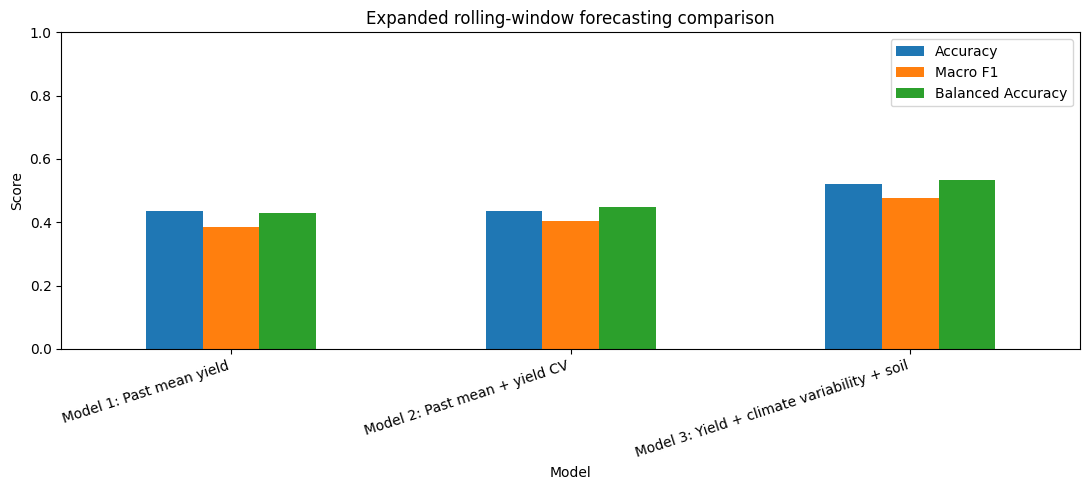

In [49]:
plot_df = expanded_results_df.set_index("Model")[
    ["Accuracy", "Macro F1", "Balanced Accuracy"]
]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Expanded rolling-window forecasting comparison")
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.show()


# PART B — Strict walk-forward validation

For each test origin, the model is trained only on rolling samples whose **target window ends before the new test target begins**.

Folds:

- Train earlier completed targets → test 2015–2017 features predicting 2018–2020
- Expand training → test 2016–2018 features predicting 2019–2021
- Expand training → test 2017–2019 features predicting 2020–2022

This is stricter than Part A and is the safer rolling-window validation result for publication.


In [50]:
walk_origins = [2015, 2016, 2017]

walk_predictions = {name: [] for name in feature_sets}
walk_truth = []
walk_fold_rows = []

for origin in walk_origins:
    test_fold = wdf[wdf["feat_start"] == origin].copy()

    test_target_start = int(test_fold["targ_start"].iloc[0])

    train_fold = wdf[
        wdf["targ_end"] < test_target_start
    ].copy()

    q33, q67 = fit_risk_thresholds(train_fold)

    train_fold["risk"] = apply_risk_label(
        train_fold["target_cv"], q33, q67
    )
    test_fold["risk"] = apply_risk_label(
        test_fold["target_cv"], q33, q67
    )

    walk_truth.extend(test_fold["risk"].tolist())

    print(
        f"Origin {origin}: "
        f"train={len(train_fold)}, "
        f"test={len(test_fold)}, "
        f"target={int(test_fold['targ_start'].iloc[0])}-"
        f"{int(test_fold['targ_end'].iloc[0])}"
    )

    for name, features in feature_sets.items():
        model, pred = train_and_predict(
            train_fold,
            test_fold,
            features,
            n_estimators=200,
            min_samples_leaf=1
        )

        walk_predictions[name].extend(pred.tolist())

        row = metrics_row(name, test_fold["risk"], pred)
        row["Test feature start"] = origin
        row["Train n"] = len(train_fold)
        row["Test n"] = len(test_fold)
        walk_fold_rows.append(row)

walk_fold_df = pd.DataFrame(walk_fold_rows)

print("\nPer-fold results:")
walk_fold_df


Origin 2015: train=24, test=23, target=2018-2020
Origin 2016: train=48, test=23, target=2019-2021
Origin 2017: train=71, test=23, target=2020-2022

Per-fold results:


,Model,Accuracy,Weighted F1,Macro F1,Balanced Accuracy,Test feature start,Train n,Test n
0,Model 1: Past mean yield,0.347826,0.331422,0.321123,0.410774,2015,24,23
1,Model 2: Past mean + yield CV,0.260870,0.252524,0.227038,0.343434,2015,24,23
2,Model 3: Yield + climate variability + soil,0.347826,0.344786,0.293706,0.329966,2015,24,23
3,Model 1: Past mean yield,0.434783,0.440328,0.429469,0.428571,2016,48,23
4,Model 2: Past mean + yield CV,0.391304,0.378882,0.396825,0.476190,2016,48,23
5,Model 3: Yield + climate variability + soil,0.391304,0.405270,0.376768,0.400794,2016,48,23
6,Model 1: Past mean yield,0.391304,0.455717,0.283951,0.270588,2017,71,23
7,Model 2: Past mean + yield CV,0.478261,0.573427,0.386946,0.356863,2017,71,23
8,Model 3: Yield + climate variability + soil,0.391304,0.500870,0.320000,0.270588,2017,71,23


In [51]:
walk_summary_rows = []

for name in feature_sets:
    walk_summary_rows.append(
        metrics_row(
            name,
            walk_truth,
            walk_predictions[name]
        )
    )

walk_summary_df = pd.DataFrame(walk_summary_rows)

print("Aggregated strict walk-forward results:")
walk_summary_df


Aggregated strict walk-forward results:


,Model,Accuracy,Weighted F1,Macro F1,Balanced Accuracy
0,Model 1: Past mean yield,0.391304,0.404378,0.351113,0.396032
1,Model 2: Past mean + yield CV,0.376812,0.417056,0.357585,0.428571
2,Model 3: Yield + climate variability + soil,0.376812,0.412658,0.327430,0.354365


# PART C — Final 2019–2022 holdout

This directly matches the mentor's wording:

**features from 2016–2018 → instability during 2019–2022**

The model is trained only on rolling samples whose target ends by 2018.

This final holdout is small, but it provides the cleanest single future-period check.


In [52]:
future_rows = []

for (state, crop), g in panel.groupby(["state", "crop"]):
    g = g.sort_values("year").copy()
    years = set(g["year"].astype(int))

    feature_years = [2016, 2017, 2018]
    target_years = [2019, 2020, 2021, 2022]

    if not all(y in years for y in feature_years + target_years):
        continue

    fw = g[g["year"].isin(feature_years)]
    tw = g[g["year"].isin(target_years)]

    feat_yield_mean = fw["yield"].mean()
    feat_yield_std = fw["yield"].std()
    feat_yield_cv = (
        feat_yield_std / feat_yield_mean
        if feat_yield_mean != 0 else np.nan
    )

    feat_rain_mean = fw["annual_rainfall"].mean()
    feat_rain_std = fw["annual_rainfall"].std()
    feat_rain_cv = (
        feat_rain_std / feat_rain_mean
        if feat_rain_mean != 0 else np.nan
    )

    target_mean = tw["yield"].mean()
    target_cv = (
        tw["yield"].std() / target_mean
        if target_mean != 0 else np.nan
    )

    row = {
        "state": state,
        "crop": crop,
        "feat_yield_mean": feat_yield_mean,
        "feat_yield_std": feat_yield_std,
        "feat_yield_cv": feat_yield_cv,
        "feat_rain_mean": feat_rain_mean,
        "feat_rain_std": feat_rain_std,
        "feat_rain_cv": feat_rain_cv,
        "target_cv": target_cv
    }

    for col in soil_cols:
        row[col] = fw[col].mean()

    future_rows.append(row)

future_test = pd.DataFrame(future_rows)
undefined_future = future_test["target_cv"].isna().sum()

future_test = (
    future_test
    .dropna(subset=["target_cv"])
    .reset_index(drop=True)
)

train_strict = wdf[wdf["targ_end"] <= 2018].copy()

q33_final, q67_final = fit_risk_thresholds(train_strict)

train_strict["risk"] = apply_risk_label(
    train_strict["target_cv"], q33_final, q67_final
)
future_test["risk"] = apply_risk_label(
    future_test["target_cv"], q33_final, q67_final
)

print("Strict historical training samples:", len(train_strict))
print("Final future holdout samples:", len(future_test))
print("Excluded future rows with undefined CV:", undefined_future)

print("\nTraining distribution:")
print(train_strict["risk"].value_counts())

print("\nFuture distribution:")
print(future_test["risk"].value_counts())


Strict historical training samples: 48
Final future holdout samples: 23
Excluded future rows with undefined CV: 2

Training distribution:
risk
Low       16
Medium    16
High      16
Name: count, dtype: int64

Future distribution:
risk
Low       11
Medium     9
High       3
Name: count, dtype: int64


In [53]:
final_results = {}
final_rows = []

for name, features in feature_sets.items():
    model, pred = train_and_predict(
        train_strict,
        future_test,
        features,
        n_estimators=500,
        min_samples_leaf=2
    )

    final_results[name] = {
        "model": model,
        "pred": pred,
        "features": features
    }

    final_rows.append(
        metrics_row(name, future_test["risk"], pred)
    )

final_results_df = pd.DataFrame(final_rows)
final_results_df


,Model,Accuracy,Weighted F1,Macro F1,Balanced Accuracy
0,Model 1: Past mean yield,0.347826,0.304099,0.350476,0.404040
1,Model 2: Past mean + yield CV,0.391304,0.414761,0.390663,0.461279
2,Model 3: Yield + climate variability + soil,0.391304,0.420741,0.367624,0.380471


In [54]:
# Chance-like random baseline for the final holdout
baseline_rows = []

for seed in range(1000):
    dummy = DummyClassifier(strategy="stratified", random_state=seed)
    dummy.fit(
        train_strict[["feat_yield_mean"]],
        train_strict["risk"]
    )
    pred = dummy.predict(
        future_test[["feat_yield_mean"]]
    )

    baseline_rows.append(
        metrics_row("Random baseline", future_test["risk"], pred)
    )

baseline_df = pd.DataFrame(baseline_rows)

print("===== FINAL-HOLDOUT RANDOM BASELINE (1000 RUNS) =====")
for col in ["Accuracy", "Weighted F1", "Macro F1", "Balanced Accuracy"]:
    print(
        f"{col}: "
        f"{baseline_df[col].mean():.3f} ± {baseline_df[col].std():.3f}"
    )


===== FINAL-HOLDOUT RANDOM BASELINE (1000 RUNS) =====
Accuracy: 0.327 ± 0.101
Weighted F1: 0.339 ± 0.104
Macro F1: 0.300 ± 0.096
Balanced Accuracy: 0.326 ± 0.115


In [55]:
for name, result in final_results.items():
    pred = result["pred"]

    print("=" * 85)
    print(name)

    print(pd.Series(
        metrics_row(name, future_test["risk"], pred)
    ))

    cm = confusion_matrix(
        future_test["risk"], pred, labels=labels
    )

    print("\nConfusion matrix:")
    print(pd.DataFrame(cm, index=labels, columns=labels))

    print("\nClassification report:")
    print(classification_report(
        future_test["risk"],
        pred,
        labels=labels,
        zero_division=0
    ))


Model 1: Past mean yield
Model                Model 1: Past mean yield
Accuracy                             0.347826
Weighted F1                          0.304099
Macro F1                             0.350476
Balanced Accuracy                     0.40404
dtype: object

Confusion matrix:
        Low  Medium  High
Low       6       4     1
Medium    8       0     1
High      0       1     2

Classification report:
              precision    recall  f1-score   support

         Low       0.43      0.55      0.48        11
      Medium       0.00      0.00      0.00         9
        High       0.50      0.67      0.57         3

    accuracy                           0.35        23
   macro avg       0.31      0.40      0.35        23
weighted avg       0.27      0.35      0.30        23

Model 2: Past mean + yield CV
Model                Model 2: Past mean + yield CV
Accuracy                                  0.391304
Weighted F1                               0.414761
Macro F1            

## 7. Feature importance for the expanded M3 model

Interpret cautiously: importance describes how the fitted Random Forest uses the variables; it does not prove causality.


Top 12 features:
feat_yield_cv      0.126316
feat_yield_mean    0.094329
feat_rain_std      0.070112
feat_rain_mean     0.068588
feat_rain_cv       0.058741
p_low              0.054579
k_medium           0.043487
ph_alkaline        0.043127
ph_acidic          0.039778
ec_saline          0.038112
p_high             0.037544
k_high             0.036133
dtype: float64


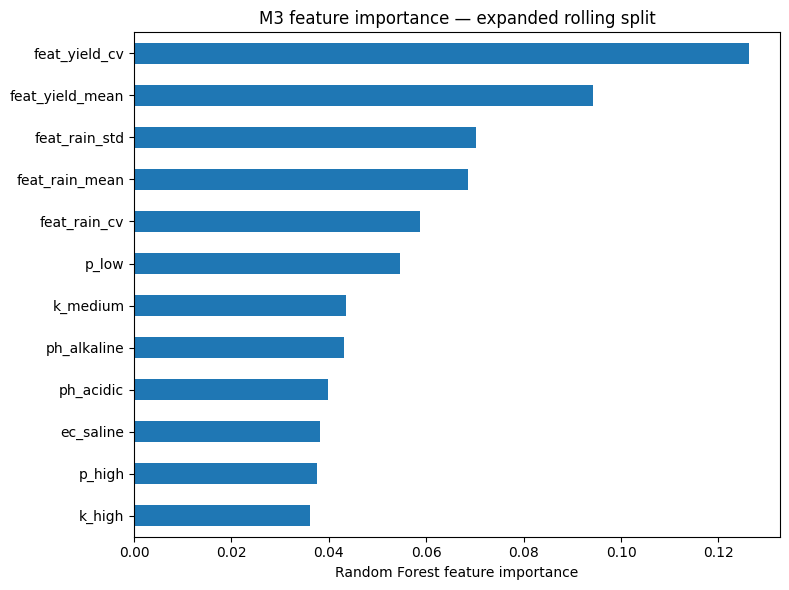

In [56]:
m3_name = "Model 3: Yield + climate variability + soil"
m3_model = expanded_results[m3_name]["model"]
m3_features = expanded_results[m3_name]["features"]

importance = (
    pd.Series(
        m3_model.feature_importances_,
        index=m3_features
    )
    .sort_values(ascending=False)
)

print("Top 12 features:")
print(importance.head(12))

importance.head(12).sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="M3 feature importance — expanded rolling split"
)
plt.xlabel("Random Forest feature importance")
plt.tight_layout()
plt.show()


# Final interpretation guide

Use the three analyses together:

### Expanded rolling-window analysis
- Demonstrates how rolling windows expand the original 25 state–crop pairs into many past→future samples.
- Useful for comparing feature sets with a larger sample.
- Because windows overlap, treat this as **expanded-sample temporal analysis**, not 140 independent observations.

### Strict walk-forward analysis
- Stronger rolling validation.
- For every fold, all training target windows finish before the new test target begins.
- Use this when explaining that the model was evaluated chronologically.

### 2019–2022 final holdout
- Directly addresses the mentor's requested future period.
- Small `n` is expected because each state–crop pair contributes one final future-instability outcome.
- Treat this as an additional strict confirmation, not as the only sample-size description.

### Key research point
The old 92% same-period classifier should not be presented as forecasting evidence because the risk label was built from the same CV used as an input. In this notebook, historical CV is separated from later-period target CV.


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logistic_final_results = {}
logistic_final_rows = []

for name, features in feature_sets.items():

    X_train = train_strict[features].copy()
    X_test = future_test[features].copy()

    y_train = train_strict["risk"]
    y_test = future_test["risk"]

    medians = X_train.median(numeric_only=True)

    X_train = X_train.fillna(medians).fillna(0)
    X_test = X_test.fillna(medians).fillna(0)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    logistic_final_results[name] = {
        "model": model,
        "pred": pred,
        "features": features
    }

    row = metrics_row(
        name,
        y_test,
        pred
    )

    logistic_final_rows.append(row)


# IMPORTANT — create dataframe
logistic_final_results_df = pd.DataFrame(logistic_final_rows)

print("LOGISTIC REGRESSION RESULTS")
display(logistic_final_results_df)

LOGISTIC REGRESSION RESULTS


,Model,Accuracy,Weighted F1,Macro F1,Balanced Accuracy
0,Model 1: Past mean yield,0.217391,0.158352,0.194152,0.333333
1,Model 2: Past mean + yield CV,0.217391,0.235513,0.214939,0.245791
2,Model 3: Yield + climate variability + soil,0.260870,0.253894,0.247970,0.289562


In [60]:
# ============================================================
# RANDOM FOREST vs LOGISTIC REGRESSION
# ============================================================

rf_comparison = final_results_df.copy()

rf_comparison["Algorithm"] = "Random Forest"

logistic_comparison = logistic_final_results_df.copy()

logistic_comparison["Algorithm"] = "Logistic Regression"

comparison_df = pd.concat(
    [
        rf_comparison,
        logistic_comparison
    ],
    ignore_index=True
)

comparison_df = comparison_df[
    [
        "Algorithm",
        "Model",
        "Accuracy",
        "Weighted F1",
        "Macro F1",
        "Balanced Accuracy"
    ]
]

print("FINAL MODEL COMPARISON")
display(comparison_df)

FINAL MODEL COMPARISON


,Algorithm,Model,Accuracy,Weighted F1,Macro F1,Balanced Accuracy
0,Random Forest,Model 1: Past mean yield,0.347826,0.304099,0.350476,0.404040
1,Random Forest,Model 2: Past mean + yield CV,0.391304,0.414761,0.390663,0.461279
2,Random Forest,Model 3: Yield + climate variability + soil,0.391304,0.420741,0.367624,0.380471
3,Logistic Regression,Model 1: Past mean yield,0.217391,0.158352,0.194152,0.333333
4,Logistic Regression,Model 2: Past mean + yield CV,0.217391,0.235513,0.214939,0.245791
5,Logistic Regression,Model 3: Yield + climate variability + soil,0.260870,0.253894,0.247970,0.289562
